In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
from scipy import signal
from scipy.ndimage import gaussian_filter1d

In [2]:
matplotlib.rc('text', usetex = True)

In [3]:
RbbTB = pd.read_csv('RbbTB036.csv',header = None, sep='\t')
RbbTS = pd.read_csv('RbbTS036.csv',header = None, sep='\t')

RqqTB = pd.read_csv('RqqTB036.csv',header = None, sep='\t')
RqqTS = pd.read_csv('RqqTS036.csv',header = None, sep='\t')

RssTB = pd.read_csv('RssTB036.csv',header = None, sep='\t')
RssTS = pd.read_csv('RssTS036.csv',header = None, sep='\t')

RqbTB = pd.read_csv('RqbTB036.csv',header = None, sep='\t')
RqbTS = pd.read_csv('RqbTS036.csv',header = None, sep='\t')

RbsTB = pd.read_csv('RbsTB036.csv',header = None, sep='\t')
RbsTS = pd.read_csv('RbsTS036.csv',header = None, sep='\t')

RqsTB = pd.read_csv('RqsTB036.csv',header = None, sep='\t')
RqsTS = pd.read_csv('RqsTS036.csv',header = None, sep='\t')

In [4]:
#1
bbTBt = RbbTB[0]
bbTB0 = RbbTB[1]
bbTB3 = RbbTB[2]
bbTB6 = RbbTB[3]
bbTSt = RbbTS[0]
bbTS0 = RbbTS[1]
bbTS3 = RbbTS[2]
bbTS6 = RbbTS[3]

#2
qqTBt = RqqTB[0]
qqTB0 = RqqTB[1]
qqTB3 = RqqTB[2]
qqTB6 = RqqTB[3]
qqTSt = RqqTS[0]
qqTS0 = RqqTS[1]
qqTS3 = RqqTS[2]
qqTS6 = RqqTS[3]

#3
ssTBt = RssTB[0]
ssTB0 = RssTB[1]
ssTB3 = RssTB[2]
ssTB6 = RssTB[3]
ssTSt = RssTS[0]
ssTS0 = RssTS[1]
ssTS3 = RssTS[2]
ssTS6 = RssTS[3]

#4
qbTBt = RqbTB[0]
qbTB0 = RqbTB[1]
qbTB3 = RqbTB[2]
qbTB6 = RqbTB[3]
qbTSt = RqbTS[0]
qbTS0 = RqbTS[1]
qbTS3 = RqbTS[2]
qbTS6 = RqbTS[3]

#5
bsTBt = RbsTB[0]
bsTB0 = RbsTB[1]
bsTB3 = RbsTB[2]
bsTB6 = RbsTB[3]
bsTSt = RbsTS[0]
bsTS0 = RbsTS[1]
bsTS3 = RbsTS[2]
bsTS6 = RbsTS[3]

#6
qsTBt = RqsTB[0]
qsTB0 = RqsTB[1]
qsTB3 = RqsTB[2]
qsTB6 = RqsTB[3]
qsTSt = RqsTS[0]
qsTS0 = RqsTS[1]
qsTS3 = RqsTS[2]
qsTS6 = RqsTS[3]

In [5]:
plt.rc('text', usetex=True)
plt.rc('font', family='Times New Roman',size=12)
plt.rcParams['mathtext.fontset']='custom'
plt.rcParams['mathtext.rm']='Times New Roman'
plt.rcParams['font.family']='Times New Roman'

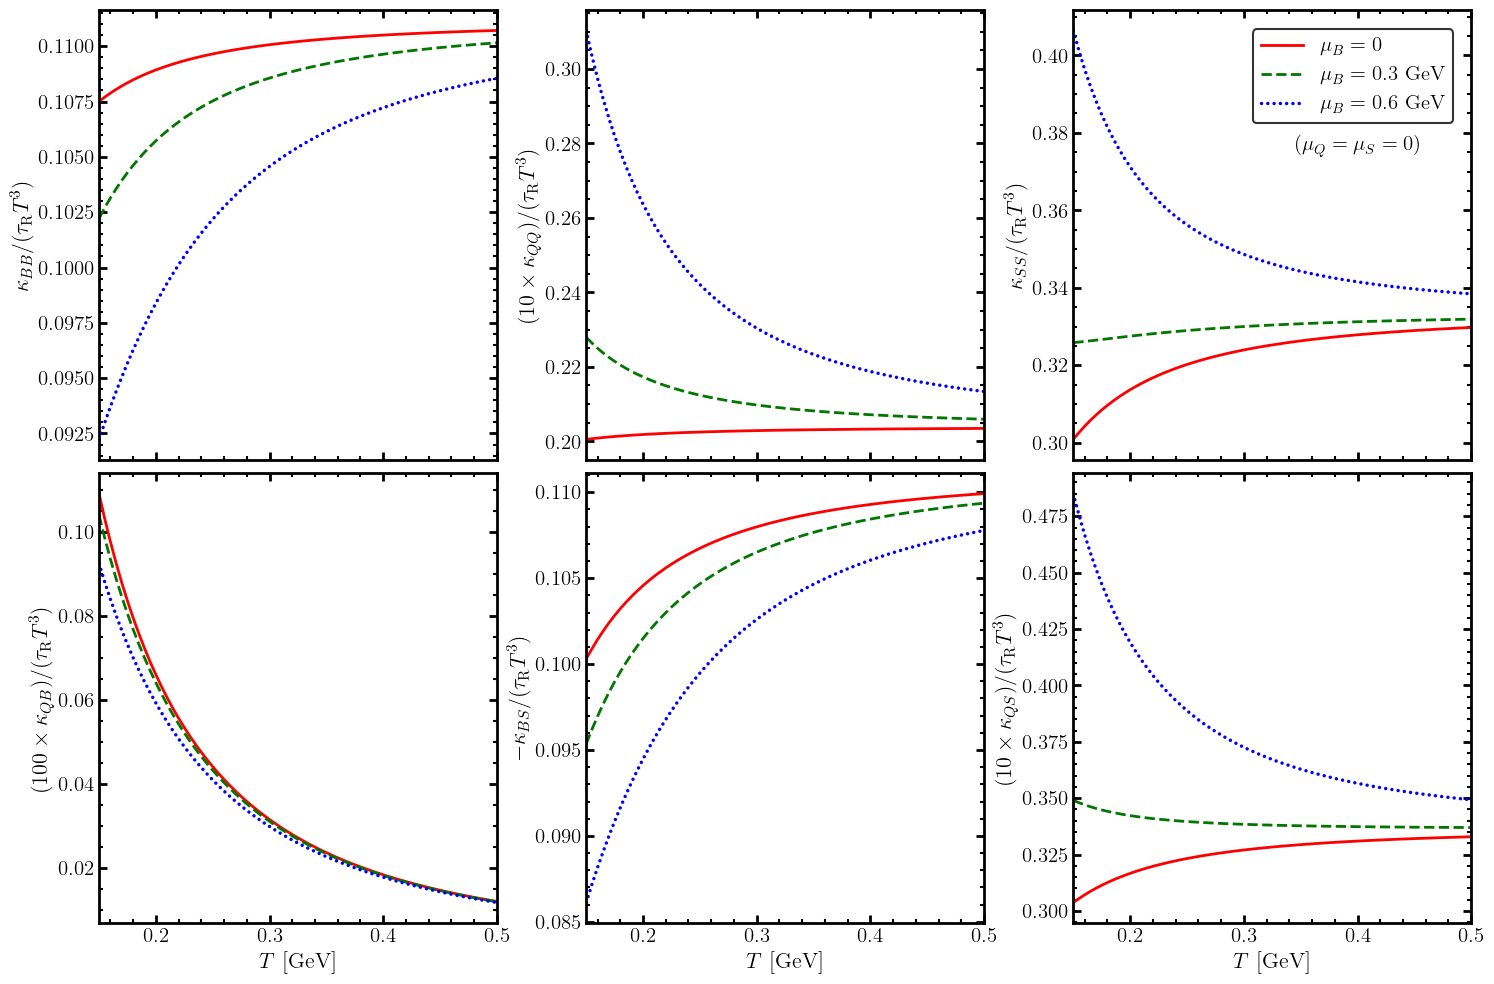

In [8]:
# 1. Organizing the variables: 6 panels 
panels_data1 = [
    [bbTBt, bbTB0, bbTB3, bbTB6], # k_bb
    [bbTBt, qqTB0, qqTB3, qqTB6], # k_qq
    [bbTBt, ssTB0, ssTB3, ssTB6], # k_ss
    [bbTBt, qbTB0, qbTB3, qbTB6], # k_qb
    [bbTBt, bsTB0, bsTB3, bsTB6], # k_bs
    [bbTBt, qsTB0, qsTB3, qsTB6], # k_qs
]

# 2. Styles for the 3 main curves
colors = ['#ff0000', '#007700', '#0000ff']
# Updated the third element with the dense, native round dot tuple
styles = ['-', '--', (0, (0.01, 1.8))]

# 3. Stripped down mathematical expressions for the Y-axes
panel_labels = [
    "$\\kappa_{BB}/(\\tau_{\\rm R} T^3)$",
    "$(10\\times\\kappa_{QQ})/(\\tau_{\\rm R} T^3)$",
    "$\\kappa_{SS}/(\\tau_{\\rm R} T^3)$",
    "$(100\\times\\kappa_{QB})/(\\tau_{\\rm R} T^3)$",
    "$-\\kappa_{BS}/(\\tau_{\\rm R} T^3)$",
    "$(10\\times\\kappa_{QS})/(\\tau_{\\rm R} T^3)$",
]

# 4. Plot Legends
plot_legend = ["$\\mu_B = 0$", "$\\mu_B = 0.3~{\\rm GeV}$", "$\\mu_B = 0.6~{\\rm GeV}$"]

# Set global frame thickness
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['patch.linewidth'] = 2.0

# 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
axes_flat = axes.flatten()

for i in range(6):  
    ax = axes_flat[i]
    current_panel_data = panels_data1[i]

    # Define clean, linear ticks appropriate for your temperature range
    custom_ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
    custom_labels = ["%g" % val for val in custom_ticks]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels(custom_labels)

    # Mirror major ticks on all sides pointing inward
    ax.tick_params(axis='both', which='major',
                   direction='in',
                   top=True,
                   right=True,
                   labelsize=15,
                   width=2.0,
                   length=6)

    # Minor ticks for a linear plot (evenly spaced sub-ticks)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor',
                   direction='in',
                   top=True,
                   right=True,
                   width=1.5,
                   length=3)

    x_val = current_panel_data[0]
    y_vals = current_panel_data[1:4]

    ax.margins(x=0)

    # --- 3 DATA CURVES ---
    for j, y_data in enumerate(y_vals):
        # Set a slightly thicker line for the dots to keep them crisp and distinct
        lw = 2.5 if j == 2 else 2
        capstyle = 'round' if j == 2 else 'butt'
        
        ax.plot(x_val, y_data,
                color=colors[j],
                linestyle=styles[j],
                linewidth=lw,
                dash_capstyle=capstyle,
                label=plot_legend[j])

    ax.grid(True, alpha=0)

    # --- MODIFIED: Reduced labelpad pulls the label closer to the y-axis values ---
    ax.set_ylabel(panel_labels[i], fontsize=16, fontweight='bold', labelpad=3)

    # Explicitly add T as the X-axis label on the bottom row panels
    if i >= 3:
        ax.set_xlabel("$T$~[GeV]", fontsize=16, fontweight='bold')

    # --- UPPER ROW RIGHT-MOST LEGEND & PLAIN TEXT ---
    if i == 2:
        # Keeps legend securely in the upper-right corner
        leg = ax.legend(
            loc='upper right',
            bbox_to_anchor=(0.98, 0.98),
            fontsize=15,
            frameon=True
        )
        leg.get_frame().set_linewidth(1.5)
        
        # Mathematical constraint description text positioned right below the box
        ax.text(0.88, 0.72, "$(\\mu_{Q} = \\mu_{S} = 0)$", 
                fontsize=15, 
                ha='right',          
                va='top',            
                transform=ax.transAxes)

# Adjusting row padding AND column padding
plt.tight_layout(h_pad=0.8, w_pad=-0.2)

plt.savefig('R1B.pdf')

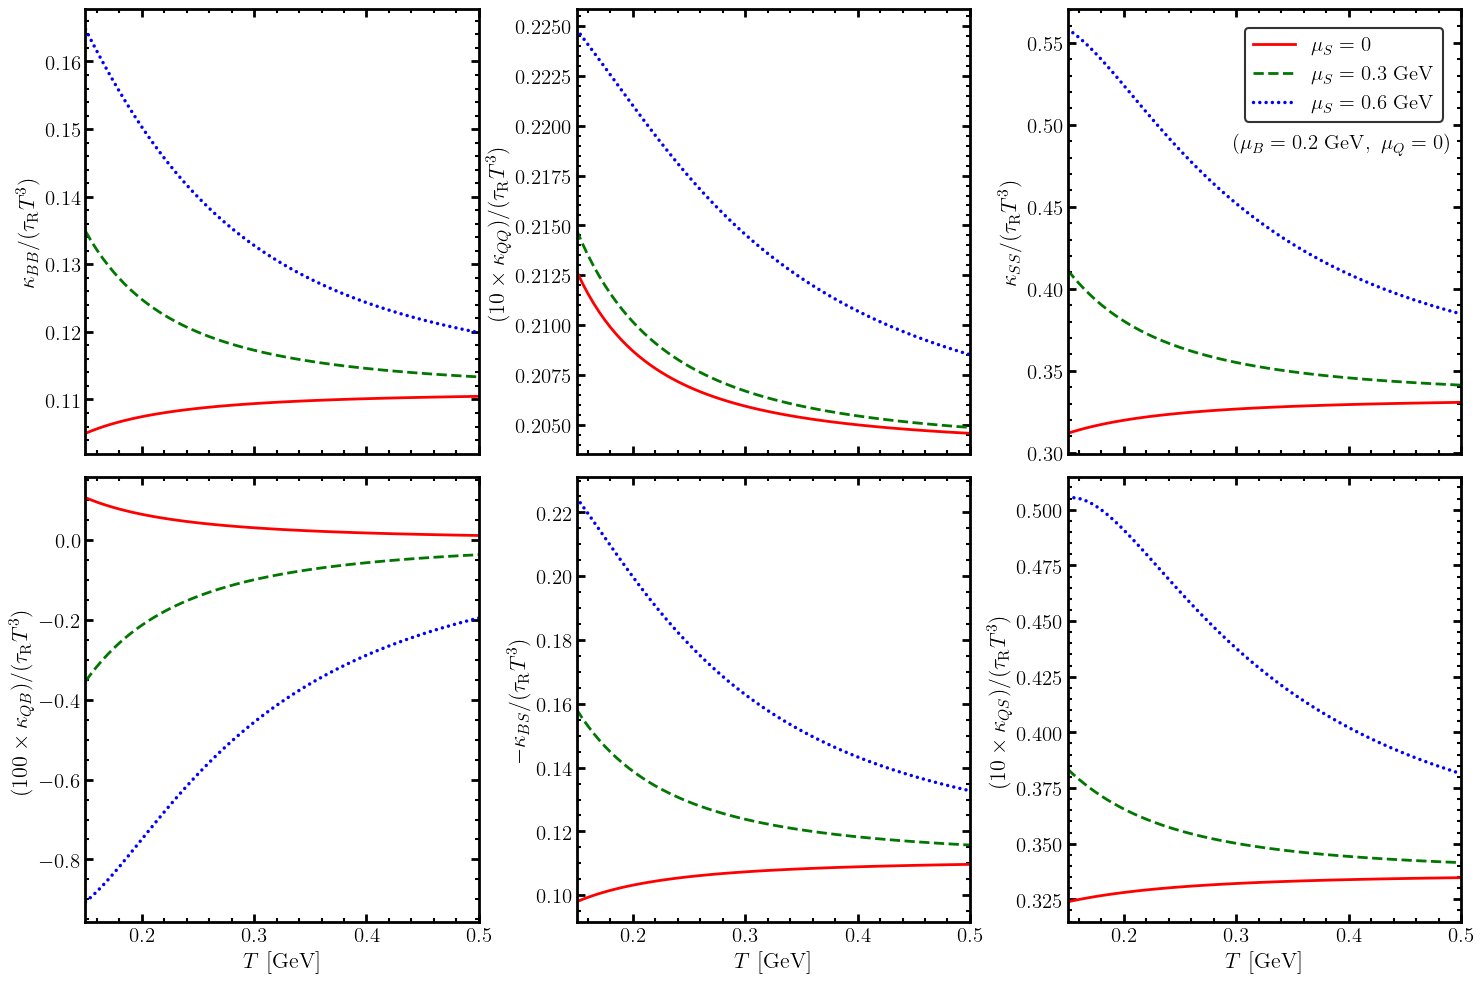

In [9]:
# 1. Organizing the variables: 6 panels 
panels_data1 = [
    [bbTSt, bbTS0, bbTS3, bbTS6], # k_bb
    [bbTSt, qqTS0, qqTS3, qqTS6], # k_qq
    [bbTSt, ssTS0, ssTS3, ssTS6], # k_ss
    [bbTSt, qbTS0, qbTS3, qbTS6], # k_qb
    [bbTSt, bsTS0, bsTS3, bsTS6], # k_bs
    [bbTSt, qsTS0, qsTS3, qsTS6], # k_qs
]

# 2. Styles for the 3 main curves
colors = ['#ff0000', '#007700', '#0000ff']
# Third element updated with the dense, native round dot tuple
styles = ['-', '--', (0, (0.01, 1.8))]

# 3. Stripped down mathematical expressions for the Y-axes
panel_labels = [
    "$\\kappa_{BB}/(\\tau_{\\rm R} T^3)$",
    "$(10\\times\\kappa_{QQ})/(\\tau_{\\rm R} T^3)$",
    "$\\kappa_{SS}/(\\tau_{\\rm R} T^3)$",
    "$(100\\times\\kappa_{QB})/(\\tau_{\\rm R} T^3)$",
    "$-\\kappa_{BS}/(\\tau_{\\rm R} T^3)$",
    "$(10\\times\\kappa_{QS})/(\\tau_{\\rm R} T^3)$",
]

# 4. Plot Legends
plot_legend = ["$\\mu_S = 0$", "$\\mu_S = 0.3~{\\rm GeV}$", "$\\mu_S = 0.6~{\\rm GeV}$"]

# Set global frame thickness
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['patch.linewidth'] = 2.0

# 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
axes_flat = axes.flatten()

for i in range(6):  
    ax = axes_flat[i]
    current_panel_data = panels_data1[i]

    # Define clean, linear ticks appropriate for your temperature range
    custom_ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
    custom_labels = ["%g" % val for val in custom_ticks]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels(custom_labels)

    # Mirror major ticks on all sides pointing inward
    ax.tick_params(axis='both', which='major',
                   direction='in',
                   top=True,
                   right=True,
                   labelsize=15,
                   width=2.0,
                   length=6)

    # Minor ticks for a linear plot (evenly spaced sub-ticks)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor',
                   direction='in',
                   top=True,
                   right=True,
                   width=1.5,
                   length=3)

    x_val = current_panel_data[0]
    y_vals = current_panel_data[1:4]

    ax.margins(x=0)

    # --- 3 DATA CURVES ---
    for j, y_data in enumerate(y_vals):
        # Slightly thicker line bounds keep the circular dots crisp and well-defined
        lw = 2.5 if j == 2 else 2
        capstyle = 'round' if j == 2 else 'butt'
        
        ax.plot(x_val, y_data,
                color=colors[j],
                linestyle=styles[j],
                linewidth=lw,
                dash_capstyle=capstyle,
                label=plot_legend[j])

    ax.grid(True, alpha=0)

    # --- MODIFIED: Reduced labelpad pulls the label closer to the y-axis values ---
    ax.set_ylabel(panel_labels[i], fontsize=16, fontweight='bold', labelpad=3)

    # Explicitly add T as the X-axis label on the bottom row panels
    if i >= 3:
        ax.set_xlabel("$T$~[GeV]", fontsize=16, fontweight='bold')

    # --- UPPER ROW RIGHT-MOST LEGEND & PLAIN TEXT ---
    if i == 2:
        # Keeps legend securely in the upper-right corner
        leg = ax.legend(
            loc='upper right',
            bbox_to_anchor=(0.98, 0.98),
            fontsize=15,
            frameon=True
        )
        leg.get_frame().set_linewidth(1.5)
        
        # Mathematical constraint description text positioned right below the box
        ax.text(0.98, 0.72, "$(\\mu_{B} = 0.2~{\\rm GeV},~\\mu_{Q} = 0)$", 
                fontsize=15, 
                ha='right',          
                va='top',            
                transform=ax.transAxes)

# Adjusting row padding AND column padding
plt.tight_layout(h_pad=0.8, w_pad=0.3)

plt.savefig('R1S.pdf')